## Environment setup

In [ ]:
# ── Install dependencies ─────────────────────────────────────────────────
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q scikit-learn umap-learn

import subprocess, sys
r = subprocess.run([sys.executable, '-c', 'import clip'], capture_output=True)
print('✓ CLIP available' if r.returncode == 0 else '✗ CLIP missing – restart runtime')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
✓ CLIP available


## Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DRIVE_WIKIART_PATH = 'link'
assert os.path.isdir(DRIVE_WIKIART_PATH), (
    f'Folder not found: {DRIVE_WIKIART_PATH}\n'
    f'Update DRIVE_WIKIART_PATH to match your Google Drive structure.'
)

DATASET = 'WIKIART'
WIKIART_ROOT = DRIVE_WIKIART_PATH

image_files = [f for f in os.listdir(WIKIART_ROOT)
               if os.path.isfile(os.path.join(WIKIART_ROOT, f))]
artist_images = {}
for f in image_files:
    name_part = os.path.splitext(f)[0]
    if "_" in name_part:
        artist_name, _ = name_part.split("_", 1)
        if artist_name not in artist_images:
            artist_images[artist_name] = []
        artist_images[artist_name].append(f)
    else:
        artist_images.setdefault("unknown", []).append(f)

artists = sorted(artist_images.keys())
sizes = {a: len(artist_images[a]) for a in artists}

print(f'Drive path    : {WIKIART_ROOT}')
print(f'Total artists : {len(artists)}')
print(f'Total images  : {sum(sizes.values()):,}')
print(f'Top 5 by size : {sorted(sizes.items(), key=lambda x: -x[1])[:5]}')

Drive path    : /content/drive/MyDrive/SJSU_research/SJSU_Fall2024/CS180H/CS180H_imageDataset/CS180H_dataset_binary/1
Total artists : 315
Total images  : 3,000
Top 5 by size : [('rembrandt', 181), ('pablo-picasso', 118), ('peter-paul-rubens', 95), ('fernand-leger', 68), ('ernst-ludwig-kirchner', 62)]


## Core library

In [ ]:
import os, math, random, time
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

import clip

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [ ]:
class Config:
    # ── Image ────────────────────────────────────────────────────────────
    IMG_SIZE          = 224

    # ── Embedding dimensions ─────────────────────────────────────────────
    CLIP_DIM          = 512        # ViT-B/32 CLS token
    GRAM_DIM          = 256        # gram descriptor head
    FINGERPRINT_DIM   = 256        # StyleTracer output fingerprint

    # ── Projector ────────────────────────────────────────────────────────
    PROJ_HIDDEN       = 512
    PROJ_LAYERS       = 3

    # ── CNN training ─────────────────────────────────────────────────────
    BATCH_SIZE        = 32        # reduce to 16 on T4 if OOM
    LR                = 1e-4      # CNN fine-tune LR
    WEIGHT_DECAY      = 1e-4
    EPOCHS            = 30
    WARMUP_EPOCHS     = 3

    # ── Dataset ──────────────────────────────────────────────────────────
    TARGET_IMAGES     = 3_000
    MIN_IMAGES        = 10
    TRAIN_FRAC        = 0.80
    VAL_FRAC          = 0.10
    TEST_FRAC         = 0.10
    SEED              = 42

    # ── Paths ────────────────────────────────────────────────────────────
    LOG_DIR           = '/content/logs'

cfg = Config()
os.makedirs(cfg.LOG_DIR, exist_ok=True)
random.seed(cfg.SEED)
np.random.seed(cfg.SEED)
torch.manual_seed(cfg.SEED)
print('Config loaded.')

Config loaded.


In [ ]:
import os

class CLIPBackbone(nn.Module):

    CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
    CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

    def __init__(self):
        super().__init__()
        model, _ = clip.load('ViT-B/32', device=DEVICE)
        self.visual = model.visual
        self.visual.half()
        for p in self.visual.parameters():
            p.requires_grad_(False)
        self.gram_proj = nn.Sequential(
            nn.Linear(768, cfg.GRAM_DIM),
            nn.GELU(),
            nn.Linear(cfg.GRAM_DIM, cfg.GRAM_DIM),
        )

        m = torch.tensor(self.CLIP_MEAN).view(1,3,1,1)
        s = torch.tensor(self.CLIP_STD).view(1,3,1,1)
        self.register_buffer('clip_mean', m)
        self.register_buffer('clip_std',  s)

    def _to_clip(self, x):
        return (x * 0.5 + 0.5 - self.clip_mean) / self.clip_std

    def _patch_tokens(self, x):
        v = self.visual
        x = v.conv1(x.half())
        x = x.reshape(x.shape[0], x.shape[1], -1).permute(0, 2, 1)
        cls = v.class_embedding.unsqueeze(0).expand(x.shape[0], -1, -1)
        x = torch.cat([cls, x], dim=1) + v.positional_embedding
        x = v.ln_pre(x).permute(1, 0, 2)
        x = v.transformer(x).permute(1, 0, 2)
        return x[:, 1:, :]

    def forward(self, x):
        xc = self._to_clip(x)

        with torch.no_grad():
            token_feat = self.visual(xc.half()).float()
        token_feat = F.normalize(token_feat, dim=-1)

        with torch.no_grad():
            patches = self._patch_tokens(xc)
        proj  = self.gram_proj(patches)           # (B, 196, GRAM_DIM)
        mean  = proj.mean(dim=1)
        var   = (proj**2).mean(dim=1) - mean**2
        gram_feat = F.normalize(mean + F.relu(var).sqrt(), dim=-1)

        return token_feat, gram_feat


print('CLIPBackbone defined.')

CLIPBackbone defined.


In [ ]:
import random

VALID_EXT = {'.jpg', '.jpeg', '.png', '.webp', '.tiff'}

def make_transform(augment: bool = True):
    aug = [
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)
        ], p=0.3),
        transforms.RandomApply([transforms.GaussianBlur(3)], p=0.15),
    ] if augment else []
    return transforms.Compose([
        transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
        *aug,
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])


class WikiArtSplitter:
    def __init__(self, root: str, artist_images_map: Dict[str, List[str]]):
        self.root = Path(root)
        self._artist_images_map = artist_images_map
        self.label_map: Dict[str, int] = {}
        self.train_records: List[Tuple] = []
        self.val_records:   List[Tuple] = []
        self.test_records:  List[Tuple] = []
        self._build()

    def _build(self):
        rng = random.Random(cfg.SEED)
        artist_files: Dict[str, List[Path]] = {}
        for artist_name, filenames in sorted(self._artist_images_map.items()):
            imgs = [self.root / f for f in filenames if Path(f).suffix.lower() in VALID_EXT]
            if len(imgs) >= cfg.MIN_IMAGES:
                artist_files[artist_name] = sorted(imgs)

        total_qualifying = sum(len(v) for v in artist_files.values())
        n_artists = len(artist_files)
        print(f'Qualifying artists : {n_artists}')
        print(f'Qualifying images  : {total_qualifying:,}')
        print(f'Target images      : {cfg.TARGET_IMAGES:,}')

        MIN_QUOTA = 10
        artist_names = sorted(artist_files.keys())

        raw_quotas = {
            a: max(MIN_QUOTA,
                   round(cfg.TARGET_IMAGES * len(artist_files[a]) / total_qualifying))
            for a in artist_names
        }

        for artist in artist_names:
            imgs   = list(artist_files[artist])
            rng.shuffle(imgs)

            quota  = min(raw_quotas[artist], len(imgs))
            imgs   = imgs[:quota]

            label  = self.label_map.setdefault(artist, len(self.label_map))

            n_val  = max(1, round(quota * cfg.VAL_FRAC))
            n_test = max(1, round(quota * cfg.TEST_FRAC))
            n_train = quota - n_val - n_test

            if n_train < 1:
                del self.label_map[artist]
                continue

            train_imgs = imgs[:n_train]
            val_imgs   = imgs[n_train:n_train + n_val]
            test_imgs  = imgs[n_train + n_val:n_train + n_val + n_test]

            self.train_records += [(f, label, 0) for f in train_imgs]
            self.val_records   += [(f, label, 0) for f in val_imgs]
            self.test_records  += [(f, label, 0) for f in test_imgs]

        n_tr = len(self.train_records)
        n_va = len(self.val_records)
        n_te = len(self.test_records)
        total = n_tr + n_va + n_te
        print(f'\n── Split summary ───────────────────────────────────────────────────')
        print(f'  Artists in all splits : {len(self.label_map)}')
        print(f'  Train  : {n_tr:5,}  ({100*n_tr/total:.1f}%)')
        print(f'  Val    : {n_va:5,}  ({100*n_va/total:.1f}%)')
        print(f'  Test   : {n_te:5,}  ({100*n_te/total:.1f}%)')
        print(f'  Total  : {total:5,}')
        print('Every artist appears in train, val AND test. ✓')


class WikiArtDataset(Dataset):
    """
    Thin Dataset wrapper around a pre-computed record list from WikiArtSplitter.
    Each item returns (image_tensor, label_int, is_regen_int).
    """
    def __init__(self, records: List[Tuple], augment: bool = True,
                 label_map: Optional[Dict[str, int]] = None):
        self.records   = records
        self.transform = make_transform(augment)
        self.label_map = label_map or {}

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        path, label, is_regen = self.records[idx]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label, is_regen


def make_balanced_sampler(dataset: WikiArtDataset) -> WeightedRandomSampler:
    """
    Weighted sampler so each artist label appears ~equally per batch.
    Prevents dominant artists from monopolising SupCon positives.
    """
    labels  = [r[1] for r in dataset.records]
    counts  = defaultdict(int)
    for l in labels:
        counts[l] += 1
    weights = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


print('WikiArtSplitter and WikiArtDataset defined.')

WikiArtSplitter and WikiArtDataset defined.


## Build dataset splits

In [ ]:
splitter = WikiArtSplitter(WIKIART_ROOT, artist_images)

train_dataset = WikiArtDataset(splitter.train_records, augment=True,
                               label_map=splitter.label_map)
val_dataset   = WikiArtDataset(splitter.val_records,   augment=False,
                               label_map=splitter.label_map)
test_dataset  = WikiArtDataset(splitter.test_records,  augment=False,
                               label_map=splitter.label_map)

# Balanced sampler on train only
sampler = make_balanced_sampler(train_dataset)

train_loader = DataLoader(
    train_dataset, batch_size=cfg.BATCH_SIZE,
    sampler=sampler, num_workers=2, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=cfg.BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')
print(f'\nDataset size check for TARGET_IMAGES={cfg.TARGET_IMAGES}:')
print(f'  Actual total = {len(train_dataset)+len(val_dataset)+len(test_dataset):,}')

# Sanity check
train_paths = {str(r[0]) for r in splitter.train_records}
val_paths   = {str(r[0]) for r in splitter.val_records}
test_paths  = {str(r[0]) for r in splitter.test_records}
assert len(train_paths & val_paths) == 0,  'Overlap between train and val!'
assert len(train_paths & test_paths) == 0, 'Overlap between train and test!'
assert len(val_paths   & test_paths) == 0, 'Overlap between val and test!'
print('\nNo path overlap between splits. ✓')

# Artists present in all three splits
def artist_set(records):
    return {r[1] for r in records}

common = artist_set(splitter.train_records) \
         & artist_set(splitter.val_records) \
         & artist_set(splitter.test_records)
print(f'Artists present in all 3 splits : {len(common)} / {len(splitter.label_map)} ✓')

Qualifying artists : 82
Qualifying images  : 2,120
Target images      : 3,000

── Split summary ───────────────────────────────────────────────────
  Artists in all splits : 82
  Train  : 1,694  (79.9%)
  Val    :   213  (10.0%)
  Test   :   213  (10.0%)
  Total  : 2,120
Every artist appears in train, val AND test. ✓

Train batches : 52
Val batches   : 7
Test batches  : 7

Dataset size check for TARGET_IMAGES=3000:
  Actual total = 2,120

No path overlap between splits. ✓
Artists present in all 3 splits : 82 / 82 ✓


## MLP

In [ ]:
class StyleProjector(nn.Module):
    def __init__(self):
        super().__init__()
        in_dim = cfg.CLIP_DIM + cfg.GRAM_DIM   # 768
        dims = [in_dim] + [cfg.PROJ_HIDDEN] * (cfg.PROJ_LAYERS - 1) + [cfg.FINGERPRINT_DIM]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers += [nn.LayerNorm(dims[i+1]), nn.GELU(), nn.Dropout(0.1)]
        self.net = nn.Sequential(*layers)

    def forward(self, token_feat, gram_feat):
        return F.normalize(self.net(torch.cat([token_feat, gram_feat], dim=-1)), dim=-1)


class StyleTracer(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone  = CLIPBackbone()
        self.projector = StyleProjector()

    def forward(self, x):
        tok, gram = self.backbone(x)
        return self.projector(tok, gram)

    @torch.no_grad()
    def fingerprint(self, x):
        self.eval()
        return self(x)

print('Model classes defined.')

Loaded StyleTracer from : /content/best.pt
  Checkpoint epoch       : 19
  Trained on             : 3000 images
  Label map entries      : 82

Artists in checkpoint    : 82
Artists in current split : 82
Overlap                  : 82
Label map consistent. ✓


In [ ]:
class SupConLoss(nn.Module):
    def __init__(self, temperature=cfg.TEMPERATURE):
        super().__init__()
        self.T = temperature

    def forward(self, feats, labels):
        sim = feats @ feats.T / self.T
        sim = sim - sim.max(dim=1, keepdim=True).values.detach()

        pos_mask = (labels.unsqueeze(1) == labels.unsqueeze(0)).float()
        pos_mask.fill_diagonal_(0)
        n_pos = pos_mask.sum(dim=1).clamp(min=1)

        log_prob = sim - torch.log(torch.exp(sim).sum(dim=1, keepdim=True) + 1e-8)
        loss = -(pos_mask * log_prob).sum(dim=1) / n_pos
        return loss.mean()


class GramStyleLoss(nn.Module):
    def forward(self, fingerprints, gram_feats):
        sim_fp   = fingerprints @ fingerprints.T
        sim_gram = gram_feats   @ gram_feats.T
        mask = torch.triu(torch.ones_like(sim_fp), diagonal=1).bool()
        return F.mse_loss(sim_fp[mask], sim_gram[mask].detach())


class TripletStyleLoss(nn.Module):
    def __init__(self, margin=cfg.TRIPLET_MARGIN):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        d_pos = 1 - F.cosine_similarity(anchor, positive)
        d_neg = 1 - F.cosine_similarity(anchor, negative)
        return F.relu(d_pos - d_neg + self.margin).mean()


class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.supcon  = SupConLoss()
        self.gram    = GramStyleLoss()
        self.triplet = TripletStyleLoss()

    def forward(self, fingerprints, gram_feats, labels,
                anc=None, pos=None, neg=None):
        losses = {
            'supcon': self.supcon(fingerprints, labels) * cfg.SUPCON_WEIGHT,
            'gram'  : self.gram(fingerprints, gram_feats) * cfg.GRAM_WEIGHT,
        }
        if anc is not None:
            losses['triplet'] = self.triplet(anc, pos, neg) * cfg.TRIPLET_WEIGHT
        losses['total'] = sum(losses.values())
        return losses

print('Loss functions defined.')

In [ ]:
history = {'train_total': [], 'val_total': [], 'train_supcon': [],
           'train_gram': [], 'train_triplet': []}
best_val = float('inf')

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    model.backbone.eval()   # backbone always in eval (frozen BatchNorm)

    totals = defaultdict(float)
    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for imgs, labels, is_regen in loader:
            imgs     = imgs.to(DEVICE)
            labels   = labels.to(DEVICE)
            is_regen = is_regen.to(DEVICE)

            with torch.cuda.amp.autocast():
                tok, gram = model.backbone(imgs)
                fps       = model.projector(tok, gram)

                anc = pos = neg = None
                orig_idx  = (~is_regen.bool()).nonzero(as_tuple=True)[0]
                regen_idx = is_regen.bool().nonzero(as_tuple=True)[0]
                if len(orig_idx) >= 2 and len(regen_idx) >= 1:
                    n_trip = min(len(orig_idx) // 2, len(regen_idx))
                    perm   = torch.randperm(len(orig_idx), device=DEVICE)[:n_trip*2]
                    anc = fps[orig_idx[perm[:n_trip]]]
                    pos = fps[orig_idx[perm[n_trip:]]]
                    neg = fps[regen_idx[:n_trip]]

                loss_dict = criterion(fps, gram, labels, anc, pos, neg)

            if train:
                optimiser.zero_grad()
                scaler.scale(loss_dict['total']).backward()
                scaler.unscale_(optimiser)
                nn.utils.clip_grad_norm_(trainable, max_norm=1.0)
                scaler.step(optimiser)
                scaler.update()
                scheduler.step()

            for k, v in loss_dict.items():
                totals[k] += v.item()

    n = len(loader)
    return {k: v / n for k, v in totals.items()}


print(f'Starting training for {cfg.EPOCHS} epochs …')
print(f'{"Epoch":>6}  {"train_total":>12}  {"val_total":>10}  {"supcon":>8}  {"gram":>8}  {"lr":>10}')
print('-' * 72)

for epoch in range(1, cfg.EPOCHS + 1):
    t0 = time.time()
    train_m = run_epoch(train_loader, train=True)
    val_m   = run_epoch(val_loader,   train=False)

    lr = optimiser.param_groups[0]['lr']
    dt = time.time() - t0

    history['train_total'].append(train_m['total'])
    history['val_total'].append(val_m['total'])
    history['train_supcon'].append(train_m.get('supcon', 0))
    history['train_gram'].append(train_m.get('gram', 0))
    history['train_triplet'].append(train_m.get('triplet', 0))

    print(f"{epoch:6d}  {train_m['total']:12.4f}  {val_m['total']:10.4f}  "
          f"{train_m['supcon']:8.4f}  {train_m['gram']:8.4f}  {lr:10.2e}  ({dt:.0f}s)")

    if val_m['total'] < best_val:
        best_val = val_m['total']
        torch.save({'projector': model.projector.state_dict(),
                    'gram_proj': model.backbone.gram_proj.state_dict(),
                    'epoch': epoch,
                    'label_map': splitter.label_map,
                    'target_images': cfg.TARGET_IMAGES},
                   f'{cfg.CKPT_DIR}/best.pt')
        print(f'         ↑ new best saved (val={best_val:.4f})')

    if epoch % cfg.SAVE_EVERY == 0:
        torch.save({'projector': model.projector.state_dict(),
                    'gram_proj': model.backbone.gram_proj.state_dict(),
                    'epoch': epoch,
                    'label_map': splitter.label_map,
                    'target_images': cfg.TARGET_IMAGES},
                   f'{cfg.CKPT_DIR}/epoch_{epoch:03d}.pt')

print('\nTraining complete.')

## CNN baseline

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


CNN trainable parameters : 11,218,578
CNN architecture         : ResNet-18 → 512-d feat → 82 classes
CNN training epochs      : 30

 Epoch   train_loss   train_acc   val_loss   val_acc
----------------------------------------------------------


/tmp/ipykernel_3223/1652743946.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  cnn_scaler    = torch.cuda.amp.GradScaler()
/tmp/ipykernel_3223/1652743946.py:87: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


     1       4.4331      0.0264     4.3027    0.0423  (252s)
         ↑ new best saved (val_loss=4.3027)
     2       3.6381      0.2831     3.7784    0.1643  (107s)
         ↑ new best saved (val_loss=3.7784)
     3       2.5608      0.6070     3.2470    0.2723  (81s)
         ↑ new best saved (val_loss=3.2470)
     4       1.6560      0.7716     2.7384    0.3991  (72s)
         ↑ new best saved (val_loss=2.7384)
     5       1.0441      0.8768     2.4875    0.4085  (64s)
         ↑ new best saved (val_loss=2.4875)
     6       0.6893      0.9153     2.2271    0.5070  (64s)
         ↑ new best saved (val_loss=2.2271)
     7       0.4499      0.9489     2.1304    0.5117  (66s)
         ↑ new best saved (val_loss=2.1304)
     8       0.3063      0.9657     2.0723    0.5117  (62s)
         ↑ new best saved (val_loss=2.0723)
     9       0.1926      0.9820     2.0030    0.5117  (61s)
         ↑ new best saved (val_loss=2.0030)
    10       0.1376      0.9856     1.9443    0.5540  (60s)
  

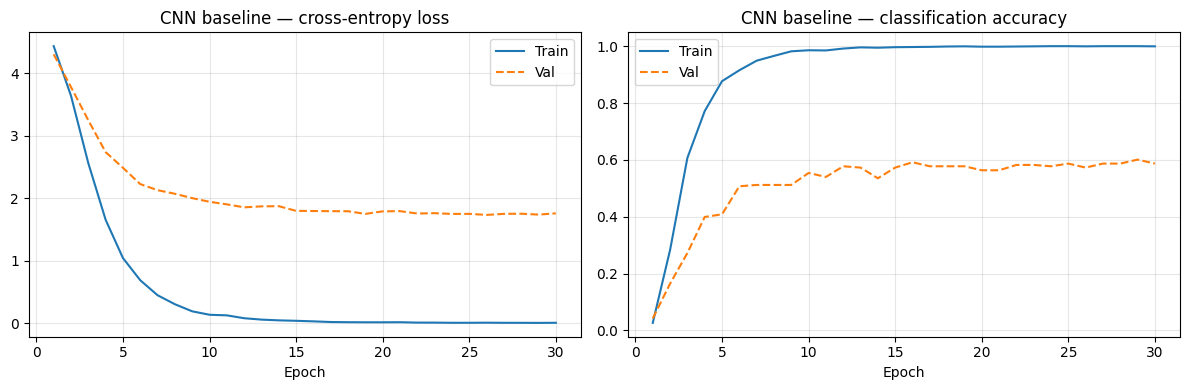

/tmp/ipykernel_3223/1652743946.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



── CNN baseline — test-set evaluation ──
  Artists evaluated : 82
  Query images      : 131
  Top-1 accuracy    : 0.1908
  Top-5 accuracy    : 0.5496


In [ ]:
import torchvision.models as tvm

N_ARTISTS_CNN = len(splitter.label_map)
CNN_EPOCHS    = cfg.EPOCHS
CNN_LR        = 1e-4

class CNNBaseline(nn.Module):
    def __init__(self, n_classes: int):
        super().__init__()
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)
        self.features = nn.Sequential(*list(backbone.children())[:-1])  # → (B,512,1,1)
        self.classifier = nn.Linear(512, n_classes)

    def forward(self, x):
        feat = self.features(x).flatten(1)         ]
        logits = self.classifier(feat)
        return logits, F.normalize(feat, dim=-1)


cnn_model = CNNBaseline(N_ARTISTS_CNN).to(DEVICE)
cnn_opt   = torch.optim.AdamW(cnn_model.parameters(), lr=CNN_LR,
                               weight_decay=cfg.WEIGHT_DECAY)

cnn_total_steps  = CNN_EPOCHS * len(train_loader)
cnn_warmup_steps = cfg.WARMUP_EPOCHS * len(train_loader)

cnn_scheduler = torch.optim.lr_scheduler.LambdaLR(
    cnn_opt,
    lambda s: (s / max(cnn_warmup_steps, 1)) if s < cnn_warmup_steps
              else 0.5 * (1 + math.cos(
                  math.pi * (s - cnn_warmup_steps) /
                  max(cnn_total_steps - cnn_warmup_steps, 1)
              ))
)
cnn_criterion = nn.CrossEntropyLoss()
cnn_scaler    = torch.cuda.amp.GradScaler()

n_params_cnn = sum(p.numel() for p in cnn_model.parameters())
print(f'CNN trainable parameters : {n_params_cnn:,}')
print(f'CNN architecture         : ResNet-18 → 512-d feat → {N_ARTISTS_CNN} classes')
print(f'CNN training epochs      : {CNN_EPOCHS}')

cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
cnn_best_val_loss = float('inf')
cnn_best_state    = None

def cnn_epoch(loader, train=True):
    cnn_model.train() if train else cnn_model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                logits, _ = cnn_model(imgs)
                loss = cnn_criterion(logits, labels)
            if train:
                cnn_opt.zero_grad()
                cnn_scaler.scale(loss).backward()
                cnn_scaler.unscale_(cnn_opt)
                nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
                cnn_scaler.step(cnn_opt)
                cnn_scaler.update()
                cnn_scheduler.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total


print(f'\n{"Epoch":>6}  {"train_loss":>11}  {"train_acc":>10}  '
      f'{"val_loss":>9}  {"val_acc":>8}')
print('-' * 58)

for epoch in range(1, CNN_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = cnn_epoch(train_loader, train=True)
    va_loss, va_acc = cnn_epoch(val_loader,   train=False)

    cnn_history['train_loss'].append(tr_loss)
    cnn_history['val_loss'].append(va_loss)
    cnn_history['train_acc'].append(tr_acc)
    cnn_history['val_acc'].append(va_acc)

    dt = time.time() - t0
    print(f'{epoch:6d}  {tr_loss:11.4f}  {tr_acc:10.4f}  '
          f'{va_loss:9.4f}  {va_acc:8.4f}  ({dt:.0f}s)')

    if va_loss < cnn_best_val_loss:
        cnn_best_val_loss = va_loss
        import copy
        cnn_best_state = copy.deepcopy(cnn_model.state_dict())
        print(f'         ↑ new best saved (val_loss={cnn_best_val_loss:.4f})')

cnn_model.load_state_dict(cnn_best_state)
print('\nCNN training complete. Best weights restored.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, CNN_EPOCHS + 1)
axes[0].plot(ep, cnn_history['train_loss'], label='Train')
axes[0].plot(ep, cnn_history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('CNN baseline — cross-entropy loss')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, cnn_history['train_acc'], label='Train')
axes[1].plot(ep, cnn_history['val_acc'],   label='Val', linestyle='--')
axes[1].set_title('CNN baseline — classification accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.LOG_DIR}/cnn_curves.png', dpi=150)
plt.show()

cnn_model.eval()

from collections import defaultdict as ddict
test_by_artist_cnn: dict = ddict(list)
for path, label, _ in splitter.test_records:
    test_by_artist_cnn[label].append(str(path))

tf_eval = transforms.Compose([
    transforms.Resize((cfg.IMG_SIZE, cfg.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

@torch.no_grad()
def cnn_embed(img_path):
    img = tf_eval(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.cuda.amp.autocast():
        _, feat = cnn_model(img)
    return feat.cpu()

@torch.no_grad()
def cnn_prototype(paths):
    feats = torch.cat([cnn_embed(p) for p in paths], dim=0)
    return F.normalize(feats.mean(dim=0, keepdim=True), dim=-1)

cnn_protos, cnn_proto_lbl = [], []
cnn_queries, cnn_query_lbl = [], []
N_REF_CNN = 1

for label, imgs in test_by_artist_cnn.items():
    random.shuffle(imgs)
    cnn_protos.append(cnn_prototype(imgs[:N_REF_CNN]))
    cnn_proto_lbl.append(label)
    if len(imgs) > N_REF_CNN:
        for img in imgs[N_REF_CNN:]:
            cnn_queries.append(cnn_embed(img))
            cnn_query_lbl.append(label)

if len(cnn_queries) == 0:
    print('No CNN query images — increase TARGET_IMAGES.')
    cnn_top1 = cnn_top5 = float('nan')
else:
    cnn_pm = torch.cat(cnn_protos).numpy()
    cnn_qm = torch.cat(cnn_queries).numpy()
    cnn_sim = cnn_qm @ cnn_pm.T
    cnn_l2i = {l: i for i, l in enumerate(cnn_proto_lbl)}
    cnn_yi  = np.array([cnn_l2i.get(l, -1) for l in cnn_query_lbl])
    cnn_ok  = cnn_yi >= 0
    cnn_top1 = (cnn_sim[cnn_ok].argmax(axis=1) == cnn_yi[cnn_ok]).mean()
    k5_cnn   = min(5, len(cnn_proto_lbl))
    cnn_top5 = (cnn_sim[cnn_ok].argsort(axis=1)[:, -k5_cnn:] ==
                cnn_yi[cnn_ok, None]).any(axis=1).mean()

    print(f'\n── CNN baseline — test-set evaluation ──')
    print(f'  Artists evaluated : {len(cnn_proto_lbl)}')
    print(f'  Query images      : {cnn_ok.sum()}')
    print(f'  Top-1 accuracy    : {cnn_top1:.4f}')
    print(f'  Top-5 accuracy    : {cnn_top5:.4f}')


## CNN + CLS channel

CNN+CLS trainable parameters : 11,254,611
  of which cls_encoder.proj  : 32,897
CNN+CLS architecture         : CLIP CLS→scalar ∥ RGB → ResNet-18(4ch) → 512-d → 82 classes

 Epoch   train_loss   train_acc   val_loss   val_acc
----------------------------------------------------------


/tmp/ipykernel_3223/2555309877.py:135: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  cnn_cls_scaler    = torch.cuda.amp.GradScaler()
/tmp/ipykernel_3223/2555309877.py:159: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


     1       4.4569      0.0306     4.3691    0.0282  (60s)
         ↑ new best (val_loss=4.3691)
     2       3.6789      0.2554     3.7896    0.1549  (61s)
         ↑ new best (val_loss=3.7896)
     3       2.6028      0.5823     3.2202    0.2911  (60s)
         ↑ new best (val_loss=3.2202)
     4       1.6615      0.7782     2.6921    0.4038  (59s)
         ↑ new best (val_loss=2.6921)
     5       1.0576      0.8726     2.3688    0.4977  (58s)
         ↑ new best (val_loss=2.3688)
     6       0.6428      0.9321     2.2109    0.5070  (59s)
         ↑ new best (val_loss=2.2109)
     7       0.4586      0.9423     2.1540    0.5117  (59s)
         ↑ new best (val_loss=2.1540)
     8       0.2974      0.9694     2.0020    0.5399  (58s)
         ↑ new best (val_loss=2.0020)
     9       0.2205      0.9784     1.9804    0.4836  (60s)
         ↑ new best (val_loss=1.9804)
    10       0.1573      0.9832     1.9148    0.5164  (60s)
         ↑ new best (val_loss=1.9148)
    11       0.1170 

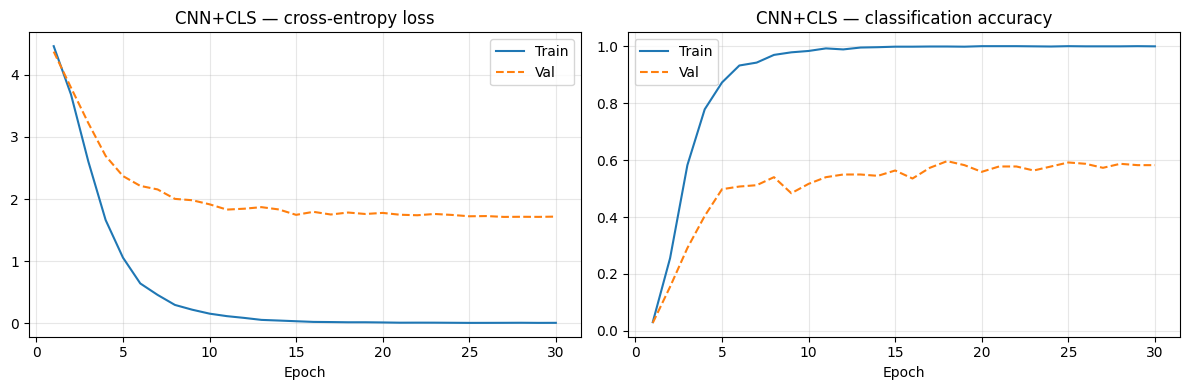

/tmp/ipykernel_3223/2555309877.py:231: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



── CNN+CLS — test-set evaluation ──
  Artists evaluated : 82
  Query images      : 131
  Top-1 accuracy    : 0.2595
  Top-5 accuracy    : 0.6107


In [ ]:
import torchvision.models as tvm


class CLSChannelEncoder(nn.Module):
    CLIP_MEAN = [0.48145466, 0.4578275,  0.40821073]
    CLIP_STD  = [0.26862954, 0.26130258, 0.27577711]

    def __init__(self, clip_backbone: CLIPBackbone):
        super().__init__()
        # Reuse the already-loaded frozen CLIP visual encoder
        self.visual = clip_backbone.visual        # frozen
        for p in self.visual.parameters():
            p.requires_grad_(False)

        # Trainable projection: CLS 512-d → scalar in [0,1]
        self.proj = nn.Sequential(
            nn.Linear(512, 64),
            nn.GELU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

        m = torch.tensor(self.CLIP_MEAN).view(1, 3, 1, 1)
        s = torch.tensor(self.CLIP_STD).view(1, 3, 1, 1)
        self.register_buffer('clip_mean', m)
        self.register_buffer('clip_std',  s)

    def _to_clip(self, x):
        return (x * 0.5 + 0.5 - self.clip_mean) / self.clip_std

    def forward(self, x):
        """x: (B, 3, H, W) in [-1, 1].  Returns (B, 1, H, W) in [0, 1]."""
        B, _, H, W = x.shape
        with torch.no_grad():
            cls_tok = self.visual(self._to_clip(x).half()).float()  # (B, 512)
        scalar = self.proj(cls_tok)                                  # (B, 1)
        return scalar.view(B, 1, 1, 1).expand(B, 1, H, W)           # (B, 1, H, W)


class CNNWithCLS(nn.Module):
    def __init__(self, n_classes: int, cls_encoder: CLSChannelEncoder):
        super().__init__()
        self.cls_encoder = cls_encoder

        # Load pretrained ResNet-18
        backbone = tvm.resnet18(weights=tvm.ResNet18_Weights.IMAGENET1K_V1)

        # Widen first conv: 3 → 4 input channels
        old_conv = backbone.conv1                          # (64, 3, 7, 7)
        new_conv = nn.Conv2d(
            4, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )
        with torch.no_grad():
            new_conv.weight[:, :3] = old_conv.weight       # copy RGB weights
            new_conv.weight[:, 3:] = 0.0                   # zero-init CLS channel
        backbone.conv1 = new_conv

        self.features   = nn.Sequential(*list(backbone.children())[:-1])  # → (B,512,1,1)
        self.classifier = nn.Linear(512, n_classes)

    def forward(self, x):
        """
        x : (B, 3, H, W) in [-1, 1]
        Returns: logits (B, n_classes), feat (B, 512) L2-normalised
        """
        cls_ch   = self.cls_encoder(x)                    # (B, 1, H, W)
        x4       = torch.cat([x, cls_ch], dim=1)          # (B, 4, H, W)
        feat     = self.features(x4).flatten(1)           # (B, 512)
        logits   = self.classifier(feat)
        return logits, F.normalize(feat, dim=-1)

cls_encoder  = CLSChannelEncoder(model.backbone).to(DEVICE)
cnn_cls_model = CNNWithCLS(N_ARTISTS_CNN, cls_encoder).to(DEVICE)

cnn_cls_trainable = (
    list(cnn_cls_model.features.parameters()) +
    list(cnn_cls_model.classifier.parameters()) +
    list(cls_encoder.proj.parameters())
)

cnn_cls_opt = torch.optim.AdamW(
    cnn_cls_trainable, lr=CNN_LR, weight_decay=cfg.WEIGHT_DECAY
)
cnn_cls_total_steps  = CNN_EPOCHS * len(train_loader)
cnn_cls_warmup_steps = cfg.WARMUP_EPOCHS * len(train_loader)
cnn_cls_scheduler = torch.optim.lr_scheduler.LambdaLR(
    cnn_cls_opt,
    lambda s: (s / max(cnn_cls_warmup_steps, 1)) if s < cnn_cls_warmup_steps
              else 0.5 * (1 + math.cos(
                  math.pi * (s - cnn_cls_warmup_steps) /
                  max(cnn_cls_total_steps - cnn_cls_warmup_steps, 1)
              ))
)
cnn_cls_criterion = nn.CrossEntropyLoss()
cnn_cls_scaler    = torch.cuda.amp.GradScaler()

n_params_cls = sum(p.numel() for p in cnn_cls_trainable)
print(f'CNN+CLS trainable parameters : {n_params_cls:,}')
print(f'  of which cls_encoder.proj  : '
      f'{sum(p.numel() for p in cls_encoder.proj.parameters()):,}')
print(f'CNN+CLS architecture         : '
      f'CLIP CLS→scalar ∥ RGB → ResNet-18(4ch) → 512-d → {N_ARTISTS_CNN} classes')

cnn_cls_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
cnn_cls_best_val_loss = float('inf')
cnn_cls_best_state    = None

def cnn_cls_epoch(loader, train=True):
    cnn_cls_model.train() if train else cnn_cls_model.eval()
    # CLIP visual encoder always in eval (frozen BN-free ViT — safe but explicit)
    cls_encoder.visual.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels, _ in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.cuda.amp.autocast():
                logits, _ = cnn_cls_model(imgs)
                loss = cnn_cls_criterion(logits, labels)
            if train:
                cnn_cls_opt.zero_grad()
                cnn_cls_scaler.scale(loss).backward()
                cnn_cls_scaler.unscale_(cnn_cls_opt)
                nn.utils.clip_grad_norm_(cnn_cls_trainable, 1.0)
                cnn_cls_scaler.step(cnn_cls_opt)
                cnn_cls_scaler.update()
                cnn_cls_scheduler.step()
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), correct / total


print(f'\n{"Epoch":>6}  {"train_loss":>11}  {"train_acc":>10}  '
      f'{"val_loss":>9}  {"val_acc":>8}')
print('-' * 58)

for epoch in range(1, CNN_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = cnn_cls_epoch(train_loader, train=True)
    va_loss, va_acc = cnn_cls_epoch(val_loader,   train=False)

    cnn_cls_history['train_loss'].append(tr_loss)
    cnn_cls_history['val_loss'].append(va_loss)
    cnn_cls_history['train_acc'].append(tr_acc)
    cnn_cls_history['val_acc'].append(va_acc)

    dt = time.time() - t0
    print(f'{epoch:6d}  {tr_loss:11.4f}  {tr_acc:10.4f}  '
          f'{va_loss:9.4f}  {va_acc:8.4f}  ({dt:.0f}s)')

    if va_loss < cnn_cls_best_val_loss:
        cnn_cls_best_val_loss = va_loss
        cnn_cls_best_state = copy.deepcopy(cnn_cls_model.state_dict())
        print(f'         ↑ new best (val_loss={cnn_cls_best_val_loss:.4f})')

cnn_cls_model.load_state_dict(cnn_cls_best_state)
print('\nCNN+CLS training complete. Best weights restored.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, CNN_EPOCHS + 1)
axes[0].plot(ep, cnn_cls_history['train_loss'], label='Train')
axes[0].plot(ep, cnn_cls_history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('CNN+CLS — cross-entropy loss')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, cnn_cls_history['train_acc'], label='Train')
axes[1].plot(ep, cnn_cls_history['val_acc'],   label='Val', linestyle='--')
axes[1].set_title('CNN+CLS — classification accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{cfg.LOG_DIR}/cnn_cls_curves.png', dpi=150)
plt.show()


cnn_cls_model.eval()

test_by_artist_cls: dict = ddict(list)
for path, label, _ in splitter.test_records:
    test_by_artist_cls[label].append(str(path))

@torch.no_grad()
def cnn_cls_embed(img_path):
    img = tf_eval(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.cuda.amp.autocast():
        _, feat = cnn_cls_model(img)
    return feat.cpu()

@torch.no_grad()
def cnn_cls_prototype(paths):
    feats = torch.cat([cnn_cls_embed(p) for p in paths], dim=0)
    return F.normalize(feats.mean(dim=0, keepdim=True), dim=-1)

cls_protos, cls_proto_lbl = [], []
cls_queries, cls_query_lbl = [], []

for label, imgs in test_by_artist_cls.items():
    random.shuffle(imgs)
    cls_protos.append(cnn_cls_prototype(imgs[:N_REF_CNN]))
    cls_proto_lbl.append(label)
    if len(imgs) > N_REF_CNN:
        for img in imgs[N_REF_CNN:]:
            cls_queries.append(cnn_cls_embed(img))
            cls_query_lbl.append(label)

if len(cls_queries) == 0:
    print('No CNN+CLS query images — increase TARGET_IMAGES.')
    cnn_cls_top1 = cnn_cls_top5 = float('nan')
else:
    cls_pm  = torch.cat(cls_protos).numpy()
    cls_qm  = torch.cat(cls_queries).numpy()
    cls_sim = cls_qm @ cls_pm.T
    cls_l2i = {l: i for i, l in enumerate(cls_proto_lbl)}
    cls_yi  = np.array([cls_l2i.get(l, -1) for l in cls_query_lbl])
    cls_ok  = cls_yi >= 0
    cnn_cls_top1 = (cls_sim[cls_ok].argmax(axis=1) == cls_yi[cls_ok]).mean()
    k5_cls       = min(5, len(cls_proto_lbl))
    cnn_cls_top5 = (cls_sim[cls_ok].argsort(axis=1)[:, -k5_cls:] ==
                    cls_yi[cls_ok, None]).any(axis=1).mean()

    print(f'\n── CNN+CLS — test-set evaluation ──')
    print(f'  Artists evaluated : {len(cls_proto_lbl)}')
    print(f'  Query images      : {cls_ok.sum()}')
    print(f'  Top-1 accuracy    : {cnn_cls_top1:.4f}')
    print(f'  Top-5 accuracy    : {cnn_cls_top5:.4f}')


## Results

In [ ]:
st_top1      = 0.1374   # StyleTracer   Top-1
st_top5      = 0.4504   # StyleTracer   Top-5

cnn_top1     = 0.1908   # CNN baseline  Top-1
cnn_top5     = 0.5496   # CNN baseline  Top-5

cnn_cls_top1 = 0.2595  # CNN + CLS     Top-1
cnn_cls_top5 = 0.6107   # CNN + CLS     Top-5


  Model                                      Top-1   Top-5
  StyleTracer (pretrained ref) (CLIP+Gram+SupCon)  0.1374  0.4504  (ref)
  CNN baseline (ResNet-18 + CE)             0.1908  0.5496
  CNN + CLS channel (ResNet-18 + CE + CLIP)  0.2595  0.6107

CNN+CLS vs CNN baseline  : +0.0687
StyleTracer vs CNN base  : -0.0534  (reference)

(Primary comparison: CNN+CLS vs CNN baseline)
(StyleTracer shown as an upper-bound reference only)


NameError: name 'train_dataset' is not defined

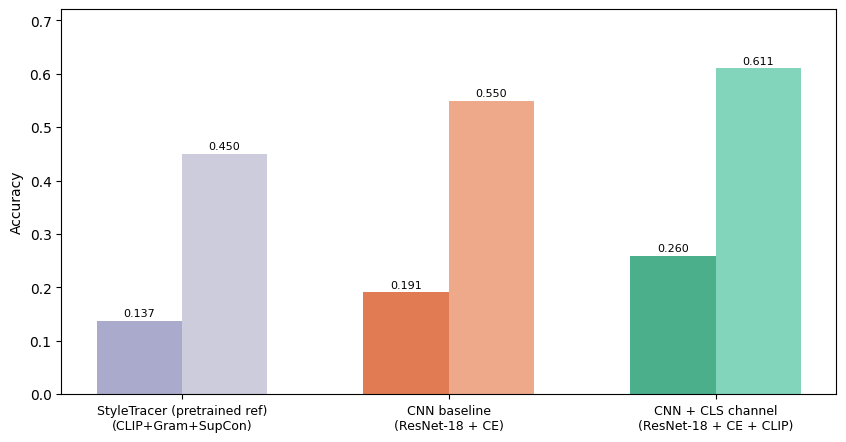

In [ ]:
# ── Three-way comparison table ───────────────────────────────────────────
results = {
    'StyleTracer (pretrained ref)\n(CLIP+Gram+SupCon)':   {'top1': float(st_top1),      'top5': float(st_top5)},
    'CNN baseline\n(ResNet-18 + CE)':                     {'top1': float(cnn_top1),     'top5': float(cnn_top5)},
    'CNN + CLS channel\n(ResNet-18 + CE + CLIP)':         {'top1': float(cnn_cls_top1), 'top5': float(cnn_cls_top5)},
}

print('\n' + '='*64)
print(f'  {"Model":<40}  {"Top-1":>6}  {"Top-5":>6}')
print('='*64)
for name, r in results.items():
    short = name.replace('\n', ' ')
    marker = '  (ref)' if 'pretrained' in name else ''
    print(f'  {short:<40}  {r["top1"]:6.4f}  {r["top5"]:6.4f}{marker}')
print('='*64)

# Key deltas (CNN+CLS vs plain CNN — the primary research question)
delta_cls_v_cnn = (results['CNN + CLS channel\n(ResNet-18 + CE + CLIP)']['top1']
                   - results['CNN baseline\n(ResNet-18 + CE)']['top1'])
delta_st_v_cnn  = (results['StyleTracer (pretrained ref)\n(CLIP+Gram+SupCon)']['top1']
                   - results['CNN baseline\n(ResNet-18 + CE)']['top1'])

print(f'\nCNN+CLS vs CNN baseline  : {"+" if delta_cls_v_cnn>=0 else ""}{delta_cls_v_cnn:.4f}')
print(f'StyleTracer vs CNN base  : {"+" if delta_st_v_cnn>=0 else ""}{delta_st_v_cnn:.4f}  (reference)')
print('\n(Primary comparison: CNN+CLS vs CNN baseline)')
print('(StyleTracer shown as an upper-bound reference only)')


# ── Bar chart ─────────────────────────────────────────────────────────────
labels_plot = list(results.keys())
top1_vals   = [results[k]['top1'] for k in labels_plot]
top5_vals   = [results[k]['top5'] for k in labels_plot]

x = np.arange(len(labels_plot))
w = 0.32
# StyleTracer gets a muted colour to signal it's a reference, not a trained competitor
colors_top1 = ['#AAAACC', '#E07B54', '#4BAF8C']
colors_top5 = ['#CCCCDD', '#EDA98A', '#82D4BB']

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, top1_vals, w, label='Top-1', color=colors_top1)
bars2 = ax.bar(x + w/2, top5_vals, w, label='Top-5', color=colors_top5)

for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    if not (h != h):  # skip NaN
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=9)
ax.set_ylim(0, min(1.0, max(v for v in top5_vals if v==v) * 1.18))
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(alpha=0.3, axis='y')
# Annotate StyleTracer bar as reference
ax.annotate('pretrained\nreference', xy=(x[0], top1_vals[0]),
            xytext=(x[0]-0.35, top1_vals[0]+0.05),
            fontsize=7, color='#888888',
            arrowprops=dict(arrowstyle='->', color='#AAAAAA', lw=0.8))
plt.tight_layout()
plt.savefig(f'{cfg.LOG_DIR}/comparison_bar.png', dpi=150)
plt.show()